Using Colab cache for faster access to the 'covid-19-nlp-text-classification' dataset.
Dataset shape: (41157, 6)


,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3799,48751,London,16-03-2020,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive
2,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive
3,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive
4,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative


PySpark DataFrame:
+--------+----------+---------+----------+------------------------------------------------------------+------------------+
|UserName|ScreenName| Location|   TweetAt|                                               OriginalTweet|         Sentiment|
+--------+----------+---------+----------+------------------------------------------------------------+------------------+
|    3799|     48751|   London|16-03-2020|@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/iFz9FAn2Pa a...|           Neutral|
|    3800|     48752|       UK|16-03-2020|advice Talk to your neighbours family to exchange phone n...|          Positive|
|    3801|     48753|Vagabonds|16-03-2020|Coronavirus Australia: Woolworths to give elderly, disabl...|          Positive|
|    3802|     48754|      NaN|16-03-2020|My food stock is not the only one which is empty...\r\r\n...|          Positive|
|    3803|     48755|      NaN|16-03-2020|Me, ready to go at supermarket during the #COVID19 outbre...|Extremely Negativ

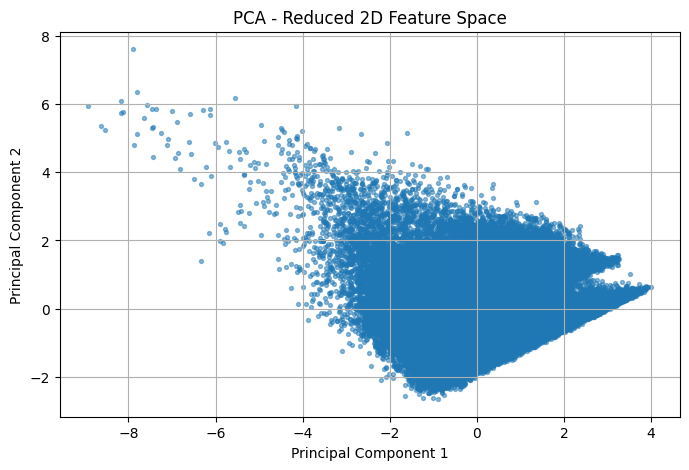

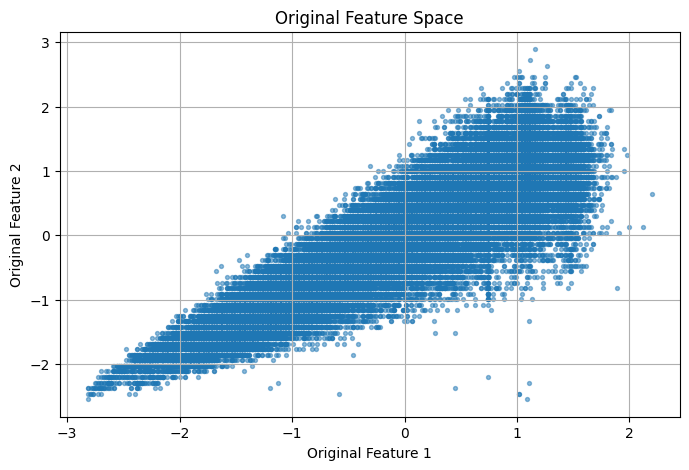


Original vs Reduced Feature Space:


,Feature Space,Number of Dimensions,Information Preserved
0,Original,8,100%
1,PCA Reduced,2,45.71%



CONCLUSION
PCA reduced the feature space from 8 dimensions to 2 principal components while preserving 45.71% of the information. The experiment shows that PCA can reduce dimensionality and simplify high-dimensional data while retaining most of its important variation.


In [2]:
# Install required libraries
!pip install -q kagglehub pyspark

# -------------------- IMPORTS --------------------
import os
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, length, regexp_replace, split, trim, when, size
)
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA


# ================================================================
# 1. LOAD DATASET USING KAGGLEHUB
# ================================================================

path = kagglehub.dataset_download(
    "datatattle/covid-19-nlp-text-classification"
)

train_path = os.path.join(path, "Corona_NLP_train.csv")

df = pd.read_csv(
    train_path,
    encoding="ISO-8859-1"
)

print("Dataset shape:", df.shape)
display(df.head())


# ================================================================
# 2. CONVERT PANDAS DATAFRAME TO PYSPARK DATAFRAME
# ================================================================

spark = (
    SparkSession.builder
    .appName("COVID_Tweet_PCA")
    .getOrCreate()
)

spark_df = spark.createDataFrame(df)

print("PySpark DataFrame:")
spark_df.show(5, truncate=60)


# ================================================================
# 3. CREATE NUMERICAL FEATURES FROM TWEETS
# ================================================================
# PCA requires numerical features.
# We derive numerical features from OriginalTweet.

spark_df = spark_df.withColumn(
    "tweet_length",
    length(col("OriginalTweet"))
).withColumn(
    "word_count",
    when(
        trim(col("OriginalTweet")) == "",
        0
    ).otherwise(
        size(split(trim(col("OriginalTweet")), r"\s+"))
    )
).withColumn(
    "hashtag_count",
    length(col("OriginalTweet")) -
    length(regexp_replace(col("OriginalTweet"), "#", ""))
).withColumn(
    "mention_count",
    length(col("OriginalTweet")) -
    length(regexp_replace(col("OriginalTweet"), "@", ""))
).withColumn(
    "url_count",
    length(col("OriginalTweet")) -
    length(
        regexp_replace(
            col("OriginalTweet"),
            "(?i)https?://",
            ""
        )
    )
).withColumn(
    "exclamation_count",
    length(col("OriginalTweet")) -
    length(regexp_replace(col("OriginalTweet"), "!", ""))
).withColumn(
    "question_count",
    length(col("OriginalTweet")) -
    length(regexp_replace(col("OriginalTweet"), r"\?", ""))
).withColumn(
    "uppercase_count",
    length(col("OriginalTweet")) -
    length(regexp_replace(col("OriginalTweet"), "[A-Z]", ""))
)

features = [
    "tweet_length",
    "word_count",
    "hashtag_count",
    "mention_count",
    "url_count",
    "exclamation_count",
    "question_count",
    "uppercase_count"
]

print("\nNumerical Features:")
spark_df.select(features).show(5)


# ================================================================
# 4. CREATE FEATURE VECTORS
# ================================================================

assembler = VectorAssembler(
    inputCols=features,
    outputCol="raw_features"
)

vector_df = assembler.transform(spark_df)

print("\nFeature Vectors:")
vector_df.select("raw_features").show(5, truncate=False)


# ================================================================
# 5. STANDARDIZE FEATURES USING STANDARD SCALER
# ================================================================

scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="scaled_features",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(vector_df)

scaled_df = scaler_model.transform(vector_df)

print("\nStandardized Features:")
scaled_df.select("scaled_features").show(5, truncate=False)


# ================================================================
# 6. APPLY PCA USING PYSPARK MLLIB
# ================================================================
# Original dimensions = 8
# Reduced dimensions = 2

pca = PCA(
    k=2,
    inputCol="scaled_features",
    outputCol="pca_features"
)

pca_model = pca.fit(scaled_df)

pca_df = pca_model.transform(scaled_df)

print("\nPCA Reduced Features:")
pca_df.select(
    "pca_features"
).show(5, truncate=False)


# ================================================================
# 7. EXPLAINED VARIANCE / INFORMATION PRESERVED
# ================================================================

variance = pca_model.explainedVariance.toArray()

print("\nExplained Variance:")
for i, v in enumerate(variance, 1):
    print(f"PC{i}: {v * 100:.2f}%")

total_variance = variance.sum() * 100

print(
    f"\nTotal Information Preserved by 2 PCs: "
    f"{total_variance:.2f}%"
)


# ================================================================
# 8. CONVERT REDUCED DATA FOR VISUALIZATION
# ================================================================

plot_df = (
    pca_df
    .select("pca_features")
    .toPandas()
)

plot_df["PC1"] = plot_df["pca_features"].apply(
    lambda x: float(x[0])
)

plot_df["PC2"] = plot_df["pca_features"].apply(
    lambda x: float(x[1])
)


# ================================================================
# 9. VISUALIZE REDUCED 2D FEATURE SPACE
# ================================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    plot_df["PC1"],
    plot_df["PC2"],
    s=8,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Reduced 2D Feature Space")
plt.grid(True)
plt.show()


# ================================================================
# 10. COMPARE ORIGINAL FEATURE SPACE
# ================================================================

original_plot = (
    scaled_df
    .select("scaled_features")
    .toPandas()
)

original_plot["Feature 1"] = original_plot[
    "scaled_features"
].apply(lambda x: float(x[0]))

original_plot["Feature 2"] = original_plot[
    "scaled_features"
].apply(lambda x: float(x[1]))


plt.figure(figsize=(8, 5))

plt.scatter(
    original_plot["Feature 1"],
    original_plot["Feature 2"],
    s=8,
    alpha=0.5
)

plt.xlabel("Original Feature 1")
plt.ylabel("Original Feature 2")
plt.title("Original Feature Space")
plt.grid(True)
plt.show()


# ================================================================
# 11. ORIGINAL VS REDUCED FEATURE SPACE
# ================================================================

comparison = pd.DataFrame({
    "Feature Space": [
        "Original",
        "PCA Reduced"
    ],
    "Number of Dimensions": [
        len(features),
        2
    ],
    "Information Preserved": [
        "100%",
        f"{total_variance:.2f}%"
    ]
})

print("\nOriginal vs Reduced Feature Space:")
display(comparison)


# ================================================================
# 12. CONCLUSION
# ================================================================

print("\nCONCLUSION")
print(
    f"PCA reduced the feature space from {len(features)} "
    f"dimensions to 2 principal components while preserving "
    f"{total_variance:.2f}% of the information. The experiment "
    f"shows that PCA can reduce dimensionality and simplify "
    f"high-dimensional data while retaining most of its "
    f"important variation."
)

spark.stop()

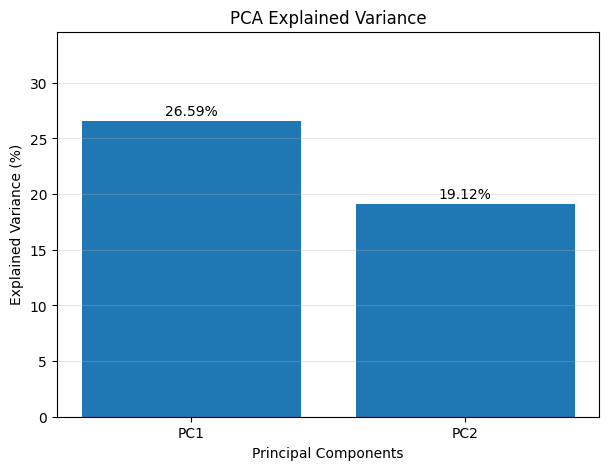

Total variance explained by selected components: 45.71%


In [3]:
# ================================================================
# ADDITIONAL: EXPLAINED VARIANCE VISUALIZATION
# ================================================================

import numpy as np
import matplotlib.pyplot as plt

pcs = [f"PC{i}" for i in range(1, len(variance) + 1)]
variance_percent = variance * 100

plt.figure(figsize=(7, 5))

bars = plt.bar(pcs, variance_percent)

plt.xlabel("Principal Components")
plt.ylabel("Explained Variance (%)")
plt.title("PCA Explained Variance")

for bar, value in zip(bars, variance_percent):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.ylim(0, max(variance_percent) + 8)
plt.grid(axis="y", alpha=0.3)
plt.show()

print(
    f"Total variance explained by selected components: "
    f"{variance_percent.sum():.2f}%"
)